## 🔹 Projeto 1 – Análise de Vendas Simples (Iniciante)

### 🎯 Objetivo Treinar:
* leitura de CSV
* limpeza básica
* groupby
* métricas simples

### 📂 Dataset Pode usar:
* Kaggle (Sales Dataset)
* Ou criar um CSV fictício com: * data * produto * categoria * quantidade * preço

### ✅ Desafios 1.
Calcular faturamento total.
2. Produto mais vendido (quantidade).
3. Categoria com maior receita.
4. Receita por mês. 5. Ticket médio por venda.

 ### 🔥 Extra * Identificar dias com vendas acima da média.

# Sales Analyst

In [ ]:
import pandas as pd

### Load the **DataFrame**

In [ ]:
dfcard = pd.read_csv("index_1.csv")

In [ ]:
# Check what payment methods are available. We have two options.
dfcard.loc[dfcard["cash_type"] == "cash"]

,date,datetime,cash_type,card,money,coffee_name
12,2024-03-02,2024-03-02 10:30:35.668,cash,NaN,40.0,Latte
18,2024-03-03,2024-03-03 10:10:43.981,cash,NaN,40.0,Latte
41,2024-03-06,2024-03-06 12:30:27.089,cash,NaN,35.0,Americano with Milk
46,2024-03-07,2024-03-07 10:08:58.945,cash,NaN,40.0,Latte
49,2024-03-07,2024-03-07 11:25:43.977,cash,NaN,40.0,Latte
...,...,...,...,...,...,...
657,2024-05-31,2024-05-31 09:23:58.791,cash,NaN,39.0,Latte
677,2024-06-01,2024-06-01 20:54:59.267,cash,NaN,39.0,Cocoa
685,2024-06-02,2024-06-02 22:43:10.636,cash,NaN,34.0,Americano with Milk
691,2024-06-03,2024-06-03 21:42:51.734,cash,NaN,34.0,Americano with Milk


In [ ]:
dfcard.head(13)

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte
5,2024-03-01,2024-03-01 15:39:47.726,card,ANON-0000-0000-0005,33.8,Americano with Milk
6,2024-03-01,2024-03-01 16:19:02.756,card,ANON-0000-0000-0006,38.7,Hot Chocolate
7,2024-03-01,2024-03-01 18:39:03.580,card,ANON-0000-0000-0007,33.8,Americano with Milk
8,2024-03-01,2024-03-01 19:22:01.762,card,ANON-0000-0000-0008,38.7,Cocoa
9,2024-03-01,2024-03-01 19:23:15.887,card,ANON-0000-0000-0008,33.8,Americano with Milk


In [ ]:
#I removed the "card" column because there's no need to include the card number in the analysis.
df_no_card = dfcard.drop(columns = "card")
df_no_card

,date,datetime,cash_type,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,38.70,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,38.70,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,38.70,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,28.90,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,38.70,Latte
...,...,...,...,...,...
3631,2025-03-23,2025-03-23 10:34:54.894,card,35.76,Cappuccino
3632,2025-03-23,2025-03-23 14:43:37.362,card,35.76,Cocoa
3633,2025-03-23,2025-03-23 14:44:16.864,card,35.76,Cocoa
3634,2025-03-23,2025-03-23 15:47:28.723,card,25.96,Americano


In [ ]:
# I checked for null values, because if there were few, I would delete them, but if there were many,
#  they would be replaced by the average of the others.
index = df_no_card[df_no_card.isna().any(axis = 1)].index
print(index)

Index([], dtype='int64')


#### Total Sales


In [ ]:
# Faturamento total
faturamento_total = df_no_card["money"].sum().round(2)
faturamento_total


np.float64(115431.58)

### Groping sales by name

##### Receita Calculate

In [ ]:
#Soma de todas as vendas por nome de cafe, DF = dfcard
per_name = df_no_card.groupby("coffee_name")["money"].sum()
per_name

,money
coffee_name,
Americano,15062.26
Americano with Milk,25269.12
Cappuccino,18034.14
Cocoa,8678.16
Cortado,7534.86
Espresso,2814.28
Hot Chocolate,10172.46
Latte,27866.30


#### Product more sell or Categoria with more receita

In [ ]:
# Use the ( .max ) for get the most value in df per_name that group per coffee name.
# And use ( idxmax ) for get the index of the most value
#Show the name of product with more sells, use the variable ( name_product )
value_max = per_name.max()
name_product = per_name.idxmax()
[value_max],[name_product]

([27866.3], ['Latte'])

In [ ]:
#Datatime transformation and Receita per month
df_no_card["date"] = pd.to_datetime(df_no_card["date"])
receita_per_month = df_no_card.groupby(df_no_card['date'].dt.month)['money'].sum()
receita_per_month

,money
date,
1,6398.86
2,13215.48
3,17036.64
4,6720.56
5,9063.42
6,7758.76
7,6915.94
8,7613.84
9,9988.64


In [ ]:
# Receita per month and by product
receita_month_by_product = df_no_card.groupby([df_no_card['date'].dt.month, "coffee_name"])['money'].sum()
receita_month_by_product

date  coffee_name        
1     Americano               649.00
      Americano with Milk    1604.72
      Cappuccino              965.52
      Cocoa                   500.64
      Cortado                 571.12
                              ...   
12    Cocoa                   750.96
      Cortado                 804.76
      Espresso                252.72
      Hot Chocolate           929.76
      Latte                  1680.72
Name: money, Length: 96, dtype: float64

#### Ticket Calculate


In [ ]:
# Ticket médio with all receipe
medium_ticket = df_no_card.groupby("coffee_name")["money"].mean().round(2)
medium_ticket

,money
coffee_name,
Americano,26.06
Americano with Milk,30.67
Cappuccino,36.00
Cocoa,35.71
Cortado,25.80
Espresso,21.00
Hot Chocolate,36.07
Latte,35.63


In [ ]:
# Ticket medium by product
ticket_month_by_product = df_no_card.groupby([df_no_card['date'].dt.month, 'coffee_name'])['money'].mean().round(2)
ticket_month_by_product

date  coffee_name        
1     Americano              25.96
      Americano with Milk    30.86
      Cappuccino             35.76
      Cocoa                  35.76
      Cortado                25.96
                             ...  
12    Cocoa                  35.76
      Cortado                25.96
      Espresso               21.06
      Hot Chocolate          35.76
      Latte                  35.76
Name: money, Length: 96, dtype: float64

## Grafics for sales


In [ ]:
#Import matplotlib for create the grafics
import matplotlib.pyplot as plt

In [ ]:
# Receita por café
per_name.plot(kind="bar")

plt.title('Revenue by product')
plt.xlabel ('Coffes')
plt.ylabel('Revenue')

plt.show()


NameError: name 'per_name' is not defined

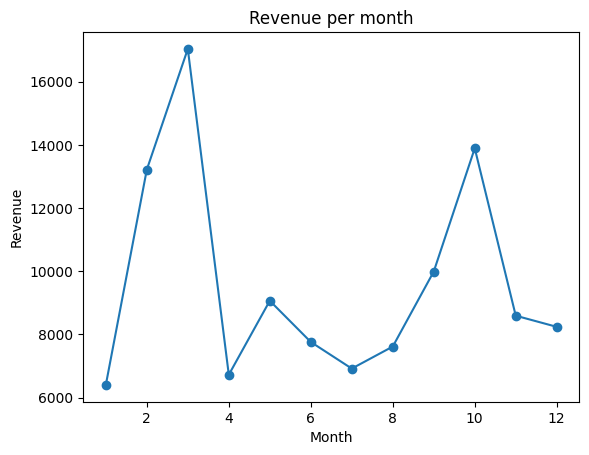

In [ ]:
# Revenue per month
receita_per_month.plot(kind="line", marker="o")

plt.title("Revenue per month")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

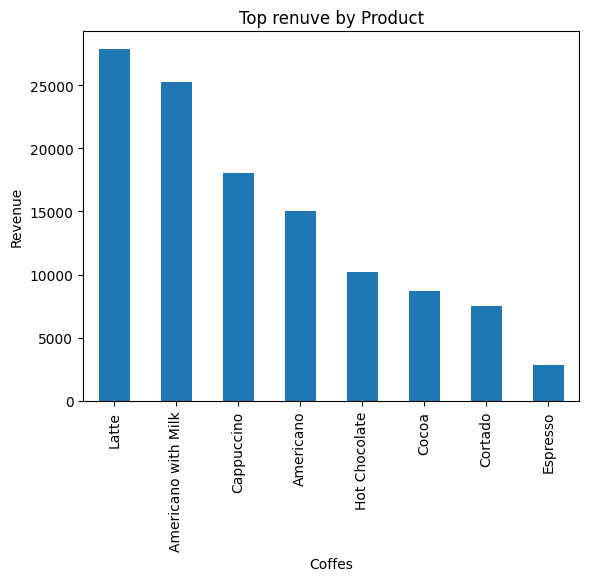

In [ ]:
# Top prduct
top = per_name.sort_values(ascending=False)

top.plot(kind="bar")

plt.title('Top renuve by Product')
plt.xlabel('Coffes')
plt.ylabel('Revenue')

plt.show()

### **Insights**

**Top Sell:** *Latte is the best selling coffee*

**Month with more Revenue:** *March had the highest revenue*

**Product with the highest average ticket price:** *it's The Hot Chocolate*